# Computing venusquake detection probabilities from a balloon platform
The code computes the probability of observing a signal with SNR > threshold at a given location or along a balloon trajectory for a variety of seismicity scenarios.

In [27]:
#%matplotlib widget
from importlib import reload
import numpy as np
import pandas as pd

import sys
sys.path.append('../')
import proba_modules as pm
reload(pm)

<module 'proba_modules' from '/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/proba_modules.py'>

## Loading background parameterrs

In [23]:
from scipy import interpolate
file_atmos = '../data/profile_VCD_for_scaling_pd.csv'
profile = pd.read_csv(file_atmos)
f_rho = interpolate.interp1d(profile.altitude/1e3, profile.rho, kind='quadratic')
f_t = interpolate.interp1d(profile.altitude/1e3, profile.t, kind='quadratic')
f_p = interpolate.interp1d(profile.altitude/1e3, profile.p, kind='quadratic')
f_gamma = interpolate.interp1d(profile.altitude/1e3, profile.gamma, kind='quadratic')
f_c = interpolate.interp1d(profile.altitude/1e3, profile.c, kind='quadratic')

In [24]:
reload(pm)
dir_GF = '../data/'
model_name = 'Cold100'
alt_balloon = 60.
opt_TL = dict(
    rho0=f_rho(0.), 
    rhob=f_rho(alt_balloon), 
    c0=f_c(0), 
    cb=f_c(alt_balloon), 
    unknown='pressure', 
    model=model_name
)

#file_curve = f'{dir_GF}GF_Dirac_1Hz_combined_wHot40.csv'
#TL_new, TL_new_qmin, TL_new_qmax = pm.get_TL_curves_precomputed(file_curve, **opt_TL)

file_curve = f'{dir_GF}GF_Dirac_1Hz_combined_wHot40_lognormal_updated_minthick.csv'
shape_new, scale_new = pm.get_lognormal_precomputed(file_curve, **opt_TL)

In [25]:
folder_slopes = '../data/Venus_data/'
file_slopes = f'{folder_slopes}distribution_venus_per_mw_geotherms_{model_name}_f1.0_updated.csv'
pd_slopes = pm.get_slopes(file_slopes)

In [26]:
file_ratio = '../data/surface_ratios/surface_ratios_active_fixed.csv'
surface_ratios = pm.get_surface_ratios(file_ratio)

## Compute probabilistic model

In [18]:
reload(pm)

dlat = 5.
r_venus = 6052
opt_model = dict(
    scenario = 'active_low_max', # Iris' seismicity scenario
    dists = np.arange(10., np.pi*r_venus, 200), # Low discretization will lead to terrible not unit integrals
    M0s = np.linspace(3., 8., 30), # Low discretization will lead to terrible not unit integrals
    SNR_thresholds = np.linspace(0.1, 10., 50),
    noise_level = 1e-2, # noise level in Pa
    duration = 1./(365.*24.), # (1/mission_duration)
    all_lats = np.arange(-89, 90, dlat),
    all_lons = np.arange(0, 359, dlat*2),
    #all_lats = np.arange(-90., 90.+dlat, dlat),
    #all_lons = np.arange(-180, 180+dlat*2, dlat*2),
    homogeneous_ratios = False,
    m_min = 3.,
    r_venus = r_venus,
    #verbose=False
    nb_CPU=1
)

freq = 1. # Or None
apply_fc_correction = None
which_TL_distribution = 'lognormal'
amplitude_model = scale_new[freq], shape_new[freq]
proba_model = pm.proba_model_CPUs(pd_slopes, surface_ratios, amplitude_model, apply_fc_correction=apply_fc_correction, which_TL_distribution=which_TL_distribution)
proba_model.compute_scores_across_CPUs(**opt_model)

Running serial


100%|██████████| 36/36 [02:05<00:00,  3.50s/it]


## Compute trajectories

In [ ]:
import VCD_trajectory_modules as VCD
reload(VCD)

alt_balloon = 50.
file_atmos = '../data/VCD_atmos_globe_new.dat'
altitude = alt_balloon*1e3
winds = VCD.get_winds(file_atmos, altitude)

start_location = [-45.,0.] # lat, lon
#start_location = [45.,0.] # lat, lon
#start_location = [85.,0.] # lat, lon
#start_location = [-45.,90.] # lat, lon
#start_location = [85., -6.6] # lat, lon
opt_trajectory = dict(
    time_max=3600*24*30*2,
    save_trajectory=False,
    folder = '../data/',
)
trajectory = VCD.compute_trajectory(winds, start_location, **opt_trajectory)

/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/VCD_trajectory_modules.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winds['gid'] = winds.groupby(['lat', 'lon'])['val'].transform('idxmin')
/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/VCD_trajectory_modules.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winds['wind_strength'] = winds.groupby(['lat', 'lon'])['val'].transform(lambda x: np.sqrt(sum(x**2)))
/staff/quentin/Documents/Pro

In [20]:
reload(pm)

snrs = proba_model.SNR_thresholds
lats, lons = proba_model.all_lats, proba_model.all_lons

####### TECTONIC #######
probas = proba_model.proba_all.copy() # SNR x lats x lons

new_trajectories = pm.compute_proba_one_trajectory(trajectory, snrs, lats, lons, probas, norm_factor_time=3600.) ## Venusquakes

100%|██████████| 3/3 [00:00<00:00, 378.70it/s]


## Compute probabilities

/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/proba_modules.py:1998: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  sc_proba = m.pcolormesh(x, y, toplot, zorder=0, cmap=cmap_p, norm=norm)


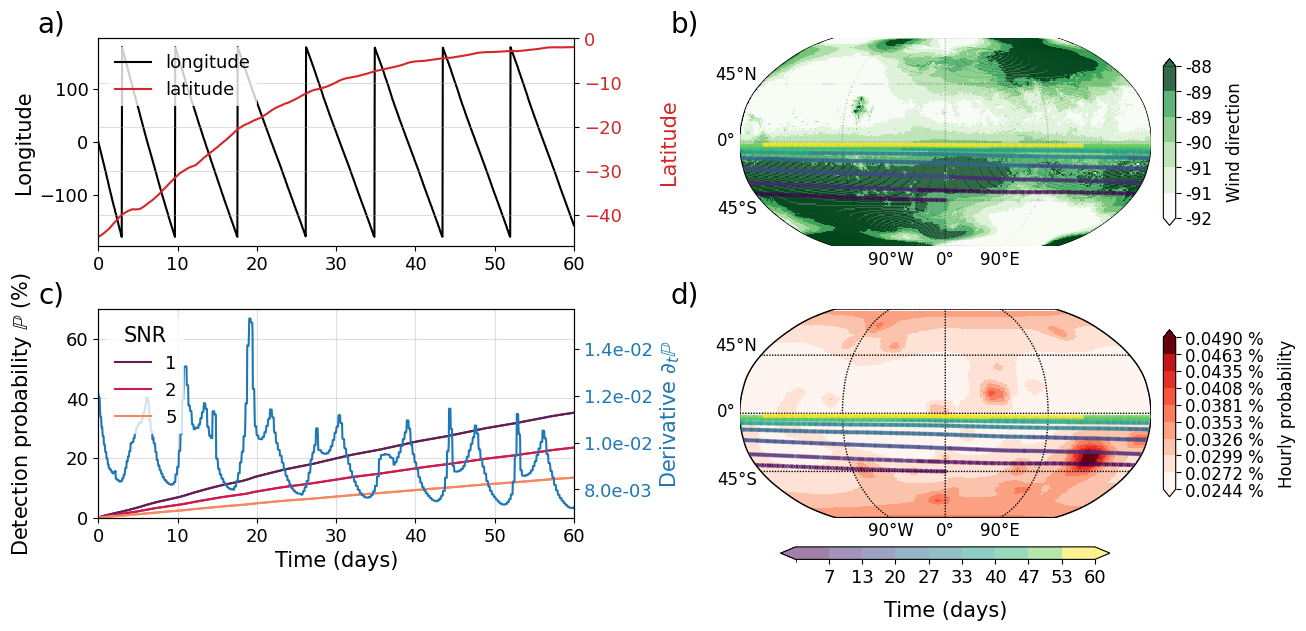

In [ ]:
reload(pm)

opt_visualization = dict(
    VENUS=None,
    snr=1., 
    n_colors=10, 
    c_cbar='black', 
    fontsize=15., 
    ylim=[0., 70.],
    plot_time=True,
    plot_volcanoes=False,
    n_colors_proba = 10, 
    n_colors_winds = 7,
    file = None
)

new_trajectories_total = new_trajectories.copy()
new_trajectories_total['seismicity'] = 'low'

####### TECTONIC #######
pm.plot_trajectory(new_trajectories_total, proba_model, winds, **opt_visualization)